In [5]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
device = torch.device("cpu") # Use CPU for explainability
print(f"Using Device: {device}")

# Paths
test_path = "../data/processed/tabular/test_data.csv"
model_path = "../models/sustainability_model.pth"

Using Device: cpu


In [6]:
# 1. Re-Define Architecture (Must match Notebook 3 EXACTLY)
class SustainabilityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()
        self.tabular_net = nn.Sequential(
            nn.Linear(4, 32), nn.ReLU(), nn.BatchNorm1d(32)
        )
        self.regressor = nn.Sequential(
            nn.Linear(512 + 32, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 1)
        )

    def forward(self, image, tabular):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_net(tabular)
        x = torch.cat([img_feat, tab_feat], dim=1)
        return self.regressor(x).squeeze(1)

# 2. Initialize and Load Weights
model = SustainabilityModel().to(device)

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Model weights loaded successfully!")
else:
    print("Error: Model file not found. Did you run the save code in Notebook 3?")

model.eval() # Set to evaluation mode

Model weights loaded successfully!


SustainabilityModel(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [8]:
# Load Test Data
df_test = pd.read_csv(test_path)
sample_idx = 10 
row = df_test.iloc[sample_idx]

def load_image_tensor(path):
    # Load and force to Float32
    img = np.load(path).astype(np.float32) 
    
    # Fix channels if needed (Keep RGB only)
    if img.shape[2] > 3: img = img[:,:,:3] 
    
    # Transpose to (Channels, Height, Width)
    img = np.transpose(img, (2, 0, 1))
    
    # Normalization (Standard ImageNet stats)
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1).astype(np.float32)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1).astype(np.float32)
    
    img = (img - mean) / std
    
    # Convert to Tensor
    return torch.tensor(img).float().unsqueeze(0).to(device)

# 1. Load Image
img_tensor = load_image_tensor(row['file_path'])

# 2. Load Tabular (FIXED: Force conversion to float32)
# Select the specific columns
subset = row[['median_income', 'population_density', 'avg_building_age', 'market_volatility']]

# FORCE conversion to numpy float32 array BEFORE converting to Tensor
tab_features = subset.values.astype(np.float32)

# Now it is safe to convert to Tensor
tab_tensor = torch.tensor(tab_features).unsqueeze(0).to(device)

print(f"Loaded Sample {sample_idx}")
print(f"Image Tensor Shape: {img_tensor.shape}")
print(f"Tabular Tensor Shape: {tab_tensor.shape}")

Loaded Sample 10
Image Tensor Shape: torch.Size([1, 3, 224, 224])
Tabular Tensor Shape: torch.Size([1, 4])


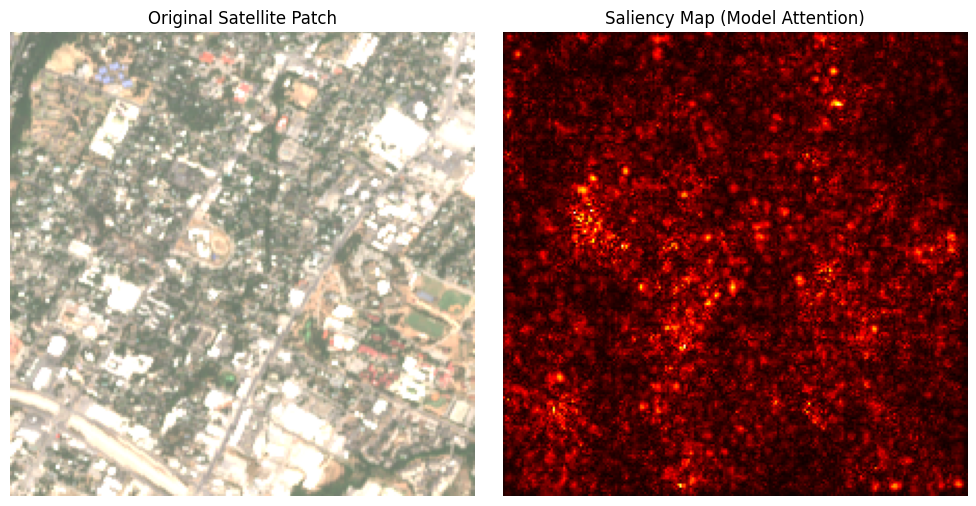

In [9]:
# Enable gradients
img_tensor.requires_grad_()

# Forward Pass
output = model(img_tensor, tab_tensor)

# Backward Pass
output.backward()

# Get Gradients
gradients = img_tensor.grad.data.abs()
gradients = gradients.squeeze(0)
gradients = gradients.max(dim=0)[0] 

# Normalize
gradients = (gradients - gradients.min()) / (gradients.max() - gradients.min())

# Plot
plt.figure(figsize=(10, 5))

# Original Image
original_img = np.load(row['file_path']).astype(np.float32)
if original_img.shape[2] > 3: original_img = original_img[:,:,:3]

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Satellite Patch")
plt.axis('off')

# Saliency Map
plt.subplot(1, 2, 2)
plt.imshow(gradients.cpu().numpy(), cmap='hot')
plt.title("Saliency Map (Model Attention)")
plt.axis('off')

plt.tight_layout()
plt.show()

Base Prediction: 0.5462


C:\Users\Yahya\AppData\Local\Temp\ipykernel_16552\1358327465.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_names, y=importances, palette="viridis")


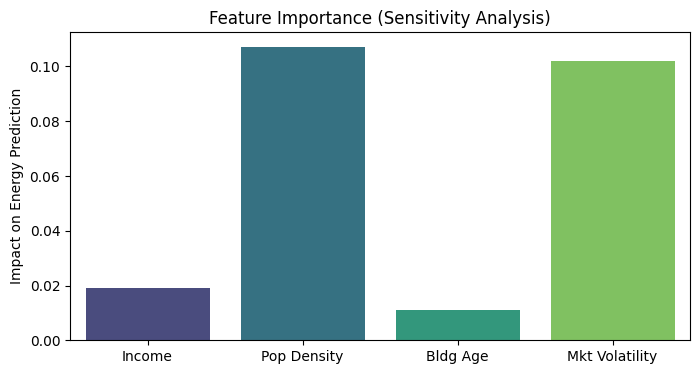

In [10]:
feature_names = ['Income', 'Pop Density', 'Bldg Age', 'Mkt Volatility']
base_pred = output.item()
importances = []

print(f"Base Prediction: {base_pred:.4f}")

with torch.no_grad():
    for i in range(4):
        temp_tab = tab_tensor.clone()
        # Add 1.0 standard deviation noise
        temp_tab[0, i] += 1.0 
        
        new_pred = model(img_tensor, temp_tab).item()
        change = abs(new_pred - base_pred)
        importances.append(change)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=feature_names, y=importances, palette="viridis")
plt.title("Feature Importance (Sensitivity Analysis)")
plt.ylabel("Impact on Energy Prediction")
plt.show()